# Copy Warren Buffett's homework, 45 days late 🐘
### The most famous free-rider trade in investing — measured, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_Berkshire_itself%3F: Busted](https://img.shields.io/badge/Beats_Berkshire_itself%3F-Busted-8b949e?style=flat-square)

Every quarter, US law forces Berkshire Hathaway to publish the stock portfolio it held 45 days earlier (a filing called a **13F**). The folk claim — repeated by guru-tracking websites, books and at least one ETF — is that you can simply **copy those ten biggest holdings when the filing drops** and still beat the market, because Buffett's picks are so good and turn over so slowly that a 45-day delay costs nothing. A free ride on the greatest investor alive.

It is a beautiful story. It is also fully testable — the filings are public, machine-readable since 2013, and the ten stocks are the most liquid names on earth. So we ran it. **The free ride went backwards.**

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A window note up front.** Machine-readable 13Fs begin in **2013**, so that is where the test begins — a mega-cap bull market in which Berkshire itself trailed the index. The famous pro-cloning study lives on 1976–2006 data. We measure the era in which *you could actually script the trade*.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from thirteen_f_cloning import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    HOLD, PX = data.load_real()
else:
    HOLD = PX = None
print("real 13F cache present:", HAVE_REAL,
      "| filings:", (0 if HOLD is None else HOLD["filing_date"].nunique()),
      "| price days:", (0 if PX is None else len(PX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2013-09-30', 'end': '2026-06-30', 'months': 154, 'years': 12.8, 'n_filings': 52, 'n_cusips': 30, 'n_priceable': 28, 'slots': '507/520', 'coverage': 97.5, 'ew': {'cagr': 8.78, 'active': -4.86, 't': -2.11, 'alpha': -4.43, 't_alpha': -1.72, 'beta': 0.97, 'sharpe': 0.49, 'dd': -30.7}, 'vw': {'cagr': 11.52, 'active': -2.27, 't': -1.07, 'alpha': -2.62, 't_alpha': -1.24, 'beta': 1.03, 'sharpe': 0.62, 'dd': -26.3}, 'ew_net10': {'cagr': 8.7, 'active': -4.94, 't': -2.14, 'drag_bps': 8.7}, 'vw_net10': {'cagr': 11.46, 'active': -2.32, 't': -1.09}, 'spy': {'cagr': 14.51, 'sharpe': 0.89, 'dd': -23.9}, 'brk_cagr': 12.43, 'vs_brk': {'ew': (-3.4, -1.16), 'vw': (-0.81, -0.23)}, 'halves': [('2013-2019', -3.84, -1.9, 76), ('2020-2026', -5.86, -1.41, 78)], 'topn': [(5, -3.39, -1.36), (10, -4.86, -2.11), (15, -3.56, -1.64)], 'rand': {'n': 200, 'mean': 0.26, 'sd': 1.53, 'cagr': 14.33, 'z': -3.34, 'pct_worse': 0.0}, 'turnover_reb': 10.0, 'nw_lags': 4, 'syn': [(0.0, -1.13, -0.76), (8.0, 5.07, 3.39)], 'fingerprint': 'ddad544e0e75', 'asof': '2026-06-30'}


real 13F cache present: True | filings: 52 | price days: 3393


## The answer first

| Question | Answer |
|---|---|
| Did copying Berkshire's top-10, 45 days late, beat the market (2013–2026)? | **No — it lost, badly.** Equal-weight clone: **8.78%/yr** vs SPY's **14.51%/yr** — about **5 points a year behind**, and statistically solid as an *underperformance*. |
| Was the 45-day delay the problem? | **No.** Trading costs and the lag together explain ~**9 bps/yr** of drag — the shortfall is ~**490 bps/yr**. The *picks themselves* lagged. |
| Would random stocks have done better? | **Yes — all of them.** 200 dart-throwing managers picking 10 names from Berkshire's *own* universe averaged **14.33%/yr**; every single one beat the real clone. |
| Did the clone at least beat Berkshire's stock (BRK-B)? | **No.** BRK-B made **12.43%/yr**; the clone made 8.78–11.52%/yr. Buying the company beat photocopying its picks. |

> The legend isn't that Buffett is overrated — it's that the *free ride* is. On every month since the trade became scriptable, the photocopier lost to the index, to chance, and to Berkshire itself.

## 1 · The claim

> *"Berkshire's holdings are public. They barely change. Buy the top ten when the 13F drops — 45 days stale — and you ride Buffett's brain for free."*

This isn't just folklore: an academic study (Martin & Puthenpurackal 2008) found that a Berkshire-mimicking portfolio beat the market by ~10%/yr on **1976–2006** data, *even bought after the public disclosure*. The question is whether the free ride survived into the era when anyone with a laptop could automate it.

## 2 · How the trade works

1. Berkshire must file **Form 13F** within **45 days** of each quarter-end, listing every US stock it holds.
2. The moment a filing lands on EDGAR (we use all **52** original filings, 2013→2026), take the **ten biggest holdings by value**.
3. Next trading day, rebalance into them — either **equal-weight** (10% each) or **Berkshire's own weights** (lately ~24% Apple, ~19% American Express...).
4. Hold until the next filing. Four trades a year. That's the whole strategy.

We charge realistic costs, use total-return prices (dividends included), and race it against the S&P 500 (SPY) and against Berkshire's own stock (BRK-B).

## 3 · The race — growth of $1

Same start line (September 2013), same tape. Watch the green line.

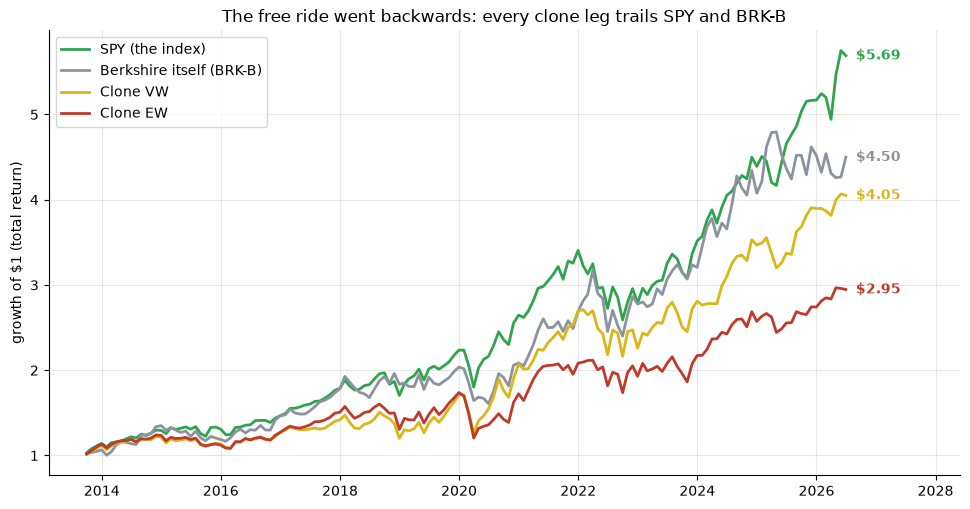

{'SPY (the index)': 5.69, 'Clone VW': 4.05, 'Clone EW': 2.95, 'Berkshire itself (BRK-B)': 4.5}


In [2]:
if HAVE_REAL:
    r_ew = st.race(PX, HOLD, weighting='ew')
    r_vw = st.race(PX, HOLD, weighting='vw')
    navs = {}
    for lab, m in [('SPY (the index)', r_ew['bench_m']), ('Clone VW', r_vw['clone_m']),
                   ('Clone EW', r_ew['clone_m'])]:
        navs[lab] = (1 + m).cumprod()
    brk_m = st.to_monthly(PX['BRK-B'].pct_change()).loc[r_ew['clone_m'].index]
    navs['Berkshire itself (BRK-B)'] = (1 + brk_m).cumprod()
    fig, ax = plt.subplots(figsize=(9.8, 5.2))
    for lab, c in [('SPY (the index)', GREEN), ('Berkshire itself (BRK-B)', GREY),
                   ('Clone VW', AMBER), ('Clone EW', RED)]:
        ax.plot(navs[lab].index, navs[lab].values, color=c, lw=2, label=lab)
        ax.annotate(f'  ${navs[lab].iloc[-1]:.2f}', (navs[lab].index[-1], navs[lab].iloc[-1]),
                    color=c, fontweight='bold', va='center')
    ax.set_ylabel('growth of $1 (total return)'); ax.set_xlim(right=navs['SPY (the index)'].index[-1] + pd.Timedelta(days=700))
    ax.set_title('The free ride went backwards: every clone leg trails SPY and BRK-B')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print({k: round(float(v.iloc[-1]), 2) for k, v in navs.items()})
else:
    print('cache missing - frozen numbers: clone EW', R['ew']['cagr'], '%/yr, VW',
          R['vw']['cagr'], '%/yr vs SPY', R['spy']['cagr'], '%/yr, BRK-B', R['brk_cagr'], '%/yr')

Over 13 years the index turned $1 into roughly $5.7, Berkshire itself about $4.5 — and the equal-weight clone about $2.9. Annualised: clone EW **8.78%/yr**, clone VW **11.52%/yr**, BRK-B **12.43%/yr**, SPY **14.51%/yr**. The value-weight clone only looks less bad because ~a quarter of it was Apple — Berkshire's one great pick of the era. The *rest* of the top ten (Kraft Heinz, IBM, Wells Fargo, the oil bets...) is what dragged.

## 4 · Was it just bad luck? Ask 200 dart-throwing monkeys

Maybe *any* ten mega-caps would have lagged the index? We let 200 random "managers" pick 10 names every quarter **from Berkshire's own universe** (the 28 names that ever made its top ten), same calendar, same 45-day lag.

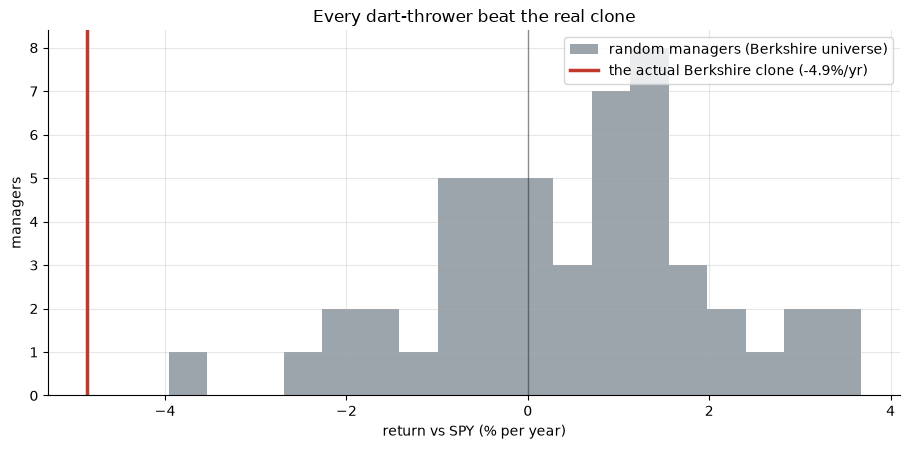

random mean +0.45%/yr | actual clone -4.86%/yr | draws as bad or worse: 0%


In [3]:
if HAVE_REAL:
    rb = st.random_manager_baseline(PX, HOLD, n_draws=50, seed=627)
    acts, ew_act = rb['actives'], r_ew['active_ann_pct']
else:
    rng = np.random.default_rng(627)
    acts = rng.normal(R['rand']['mean'], R['rand']['sd'], 50); ew_act = R['ew']['active']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.hist(acts, bins=18, color=GREY, alpha=.85, label='random managers (Berkshire universe)')
ax.axvline(0, color='k', lw=1, alpha=.4)
ax.axvline(ew_act, color=RED, lw=2.5, label=f'the actual Berkshire clone ({ew_act:+.1f}%/yr)')
ax.set_xlabel('return vs SPY (% per year)'); ax.set_ylabel('managers')
ax.set_title('Every dart-thrower beat the real clone')
ax.legend(); plt.tight_layout(); plt.show()
print(f'random mean {np.mean(acts):+.2f}%/yr | actual clone {ew_act:+.2f}%/yr | '
      f'draws as bad or worse: {(np.asarray(acts) <= ew_act).mean()*100:.0f}%')

The random managers hovered around the index (mean **+0.26%/yr** across the canonical 200 draws). The real clone sits **-3.3 standard deviations below them** — worse than **every single one**. Read that again: over this stretch, *throwing darts at Berkshire's own favourite stocks beat copying Berkshire's actual ranking of them*.

> 🔬 **For the quants:** the equal-weight clone's underperformance is statistically significant (HAC *t* = **-2.11**) — this is not "roughly flat, shrug", it is a measured negative. Details next door.

## 5 · The verdict

- **Signal — None.** The 45-day-late clone lost to the market by **-4.86%/yr** (equal-weight, HAC *t* = -2.11) and **-2.27%/yr** (Berkshire's weights) over 154 months. Negative in 2013–2019 *and* 2020–2026, negative whether you copy the top 5, 10 or 15, worse than all 200 random portfolios.
- **Tradability — Mirage.** The trade is *perfectly* executable — ten mega-caps, four trades a year, ~9 bps/yr of cost drag. Execution was never the issue; there is simply no edge to collect.
- **"At least it beats Berkshire itself?" — Busted.** BRK-B (**12.43%/yr**) beat both clones despite its famous cash pile. The photocopy lost to the original, and the original lost to the index.

The honest footnote: this is the **2013–2026** answer — the only era in which the trade was scriptable. The 1976–2006 free ride documented in the literature may well have been real; it did not survive to the era of the people reading about it.

## 6 · Going further 🚪

- **Why did it fail?** Not the lag (costs + delay ≈ a rounding error) — the *selection*. Berkshire's non-Apple top-10 of this era (KHC, IBM, WFC, OXY, VZ...) underperformed badly, and the clone is a concentrated bet on exactly those names.
- **The generic lesson.** A public, famous, capacity-free recipe attracts copiers; post-publication decay (McLean-Pontiff) is the norm, not the exception. The louder the legend, the more you should demand the *recent* tape.
- **Build your own.** The engine takes any 13F filer's CIK — swap in another guru and re-run. The claim's siblings live at [263-insider-buying](../../263-insider-buying/) (Form 4, insiders' own trades).

*Think a different guru's 13F survives the same harness? Fork the study, change one CIK, and show us the HAC t.*